# Clase 9: Introducción al Machine Learning
## Predicción de default en tarjetas de crédito
### Lasso + Random Forest

---

## ¿Qué es Machine Learning?

En econometría el objetivo es **inferencia**: entender la relación entre variables, estimar coeficientes, hacer pruebas de hipótesis. La pregunta es *¿cuánto afecta X a Y?*

En Machine Learning el objetivo es **predicción**: construir un modelo que, dado un conjunto de variables, prediga lo mejor posible el valor de Y para observaciones que no vio durante el entrenamiento. La pregunta es *¿cuánto va a ser Y?*

La diferencia tiene consecuencias:

| | Econometría | Machine Learning |
|---|---|---|
| Objetivo | Inferencia causal | Predicción fuera de muestra |
| Preocupación | Sesgo de los estimadores | Overfitting |
| Evaluación | R², p-valores | Accuracy, F1, AUC en test set |
| Modelo | Parsimonioso e interpretable | Puede ser una caja negra |

## El problema de hoy

Un banco en Taiwan tiene 30,000 clientes de tarjeta de crédito. Quiere saber **qué clientes van a entrar en default el mes que viene** para tomar decisiones preventivas.

Variable objetivo: `default` — 1 si el cliente no pagó, 0 si pagó.

Esto es **clasificación binaria** — el modelo predice una de dos categorías.

---
## Paso 0 — Instalación

In [3]:
%%capture
pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)

# semilla para reproducibilidad — equivale a set.seed() en R
np.random.seed(42)

print("Librerías cargadas ✓")

Librerías cargadas ✓


---
## Paso 1 — Descargar los datos

El dataset viene del UCI Machine Learning Repository — una colección pública de datasets para investigación. `fetch_ucirepo(id=350)` descarga exactamente el dataset de default de tarjetas de crédito de Taiwan (2005).

In [5]:
# fetch_ucirepo descarga el dataset directamente desde UCI
# id=350 es el identificador único de este dataset en el repositorio
dataset = fetch_ucirepo(id=350)

# el dataset viene separado en features (X) y target (y)
# features = las variables explicativas (lo que sabemos del cliente)
# targets  = lo que queremos predecir (¿defaulteó?)
X = dataset.data.features
y = dataset.data.targets

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nVariables disponibles:")
print(list(X.columns))

Dimensiones de X: (30000, 23)
Dimensiones de y: (30000, 1)

Variables disponibles:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


In [6]:
# ver las primeras filas
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [7]:
# descripción de cada variable
print(dataset.variables[['name', 'description']].to_string())

   name                 description
0    ID                        None
1    X1                   LIMIT_BAL
2    X2                         SEX
3    X3                   EDUCATION
4    X4                    MARRIAGE
5    X5                         AGE
6    X6                       PAY_0
7    X7                       PAY_2
8    X8                       PAY_3
9    X9                       PAY_4
10  X10                       PAY_5
11  X11                       PAY_6
12  X12                   BILL_AMT1
13  X13                   BILL_AMT2
14  X14                   BILL_AMT3
15  X15                   BILL_AMT4
16  X16                   BILL_AMT5
17  X17                   BILL_AMT6
18  X18                    PAY_AMT1
19  X19                    PAY_AMT2
20  X20                    PAY_AMT3
21  X21                    PAY_AMT4
22  X22                    PAY_AMT5
23  X23                    PAY_AMT6
24    Y  default payment next month


In [8]:
# dataset.variables tiene el mapeo name → description
# lo usamos para renombrar automáticamente
variables = dataset.variables

# crear diccionario {nombre_actual: descripcion}
# dropna() para ignorar filas sin descripción (como ID)
rename_dict = (
    variables[['name', 'description']]
    .dropna()
    .set_index('name')['description']
    .to_dict()
)

print("Mapeo de nombres:")
print(rename_dict)

# renombrar las columnas
X = X.rename(columns=rename_dict)
print("\nColumnas después de renombrar:")
print(X.columns.tolist())

Mapeo de nombres:
{'X1': 'LIMIT_BAL', 'X2': 'SEX', 'X3': 'EDUCATION', 'X4': 'MARRIAGE', 'X5': 'AGE', 'X6': 'PAY_0', 'X7': 'PAY_2', 'X8': 'PAY_3', 'X9': 'PAY_4', 'X10': 'PAY_5', 'X11': 'PAY_6', 'X12': 'BILL_AMT1', 'X13': 'BILL_AMT2', 'X14': 'BILL_AMT3', 'X15': 'BILL_AMT4', 'X16': 'BILL_AMT5', 'X17': 'BILL_AMT6', 'X18': 'PAY_AMT1', 'X19': 'PAY_AMT2', 'X20': 'PAY_AMT3', 'X21': 'PAY_AMT4', 'X22': 'PAY_AMT5', 'X23': 'PAY_AMT6', 'Y': 'default payment next month'}

Columnas después de renombrar:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [9]:
# ¿Cuántos clientes defaultearon?
# Esta es la primera pregunta que hay que hacerse antes de modelar:
# ¿qué tan desbalanceado está el dataset?

conteo = y.value_counts()
print("Distribución de la variable objetivo:")
print(conteo)
print(f"\nPorcentaje de defaults: {conteo[1] / len(y) * 100:.1f}%")
print(f"Porcentaje de no-defaults: {conteo[0] / len(y) * 100:.1f}%")

# Esto es importante: si el 78% no defaultea, un modelo que siempre prediga
# 'no default' tiene 78% de accuracy sin aprender nada útil
# por eso accuracy sola no es suficiente — lo vemos más adelante

Distribución de la variable objetivo:
Y
0    23364
1     6636
Name: count, dtype: int64

Porcentaje de defaults: 22.1%
Porcentaje de no-defaults: 77.9%


---
## Paso 2 — Exploración y limpieza

Los datos reales siempre tienen problemas. Este dataset tiene categorías no documentadas en EDUCATION y MARRIAGE que hay que manejar antes de modelar.

In [10]:
# estadísticos básicos de todas las columnas
# equivale a summary() en R
X.describe().round(2)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,47013.15,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,69349.39,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2666.25,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,20088.50,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,60164.75,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00


In [11]:
# la documentación oficial del dataset describe estas categorías:
#
# EDUCATION: 1=posgrado, 2=universidad, 3=preparatoria, 4=otros
# MARRIAGE:  1=casado, 2=soltero, 3=otros
#
# pero los datos tienen valores no documentados que hay que investigar primero

print("Valores únicos en EDUCATION:", sorted(X['EDUCATION'].unique()))
print("Valores únicos en MARRIAGE:",  sorted(X['MARRIAGE'].unique()))
print()
print("Según la documentación oficial (Yeh, 2009):")
print("  EDUCATION debería tener solo: 1, 2, 3, 4")
print("  MARRIAGE  debería tener solo: 1, 2, 3")
print()
print("Los valores 0, 5, 6 en EDUCATION y 0 en MARRIAGE")
print("no están descritos en el paper — son probablemente errores de captura")
print("o categorías no documentadas. Los agrupamos en 'otros'.")

Valores únicos en EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Valores únicos en MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Según la documentación oficial (Yeh, 2009):
  EDUCATION debería tener solo: 1, 2, 3, 4
  MARRIAGE  debería tener solo: 1, 2, 3

Los valores 0, 5, 6 en EDUCATION y 0 en MARRIAGE
no están descritos en el paper — son probablemente errores de captura
o categorías no documentadas. Los agrupamos en 'otros'.


---
## Paso 3 — Transformaciones

Tres tipos de transformaciones que vamos a hacer:

1. **Limpiar categorías no documentadas** — EDUCATION y MARRIAGE tienen valores que no deberían existir
2. **Crear variables nuevas** — ratios y tendencias que capturan información que las variables originales no expresan directamente
3. **Transformación logarítmica** — para variables con distribuciones muy sesgadas

In [12]:
# trabajamos sobre una copia para no modificar los datos originales
df = X.copy()
df['default'] = y.values   # agregar la variable objetivo al DataFrame

# ── Limpieza de categorías ────────────────────────────────────────────────────

# ¿Qué es una lambda?
# Es una función anónima — una función que no tiene nombre y se define en una línea.
# En R escribirías: function(x) ifelse(x %in% c(1,2,3,4), x, 4)
# En Python se escribe: lambda x: x if x in [1,2,3,4] else 4
#
# La sintaxis es: lambda argumento: valor_si_true if condicion else valor_si_false
# Se lee igual que un if/else normal pero en una sola línea.
#
# .apply(función) aplica esa función a cada elemento de la columna.
# Es equivalente a usar map() o sapply() en R.
#
# Entonces esta línea dice:
# "para cada valor x en EDUCATION:
#    si x está en [1, 2, 3, 4] → déjalo igual
#    si no → reemplázalo con 4 (categoría 'otros')"

# probemos la lambda sola antes de aplicarla a toda la columna
funcion_educacion = lambda x: x if x in [1, 2, 3, 4] else 4

print("Prueba de la lambda:")
for valor in [0, 1, 2, 3, 4, 5, 6]:
    print(f"  funcion_educacion({valor}) → {funcion_educacion(valor)}")

Prueba de la lambda:
  funcion_educacion(0) → 4
  funcion_educacion(1) → 1
  funcion_educacion(2) → 2
  funcion_educacion(3) → 3
  funcion_educacion(4) → 4
  funcion_educacion(5) → 4
  funcion_educacion(6) → 4


In [13]:
# ── Variables nuevas ──────────────────────────────────────────────────────────

# 1. Ratio de utilización del crédito
#    ¿Qué fracción de su límite está usando el cliente?
#    Un cliente que usa el 95% de su límite está más expuesto que uno que usa el 20%
#    BILL_AMT1 es el estado de cuenta más reciente (septiembre)
#    np.where(condicion, valor_si_true, valor_si_false) equivale a ifelse() en R
df['ratio_utilizacion'] = np.where(
    df['LIMIT_BAL'] > 0,
    df['BILL_AMT1'] / df['LIMIT_BAL'],
    0   # evitar división entre cero
)

# 2. Promedio de retraso en los últimos 6 meses
#    PAY_0 a PAY_6 = historial de pagos (-1=pagó bien, 0=mínimo, 1=mes retraso, etc.)
#    el promedio captura el comportamiento general del cliente
cols_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['promedio_retraso'] = df[cols_pay].mean(axis=1)   # axis=1 = promedio por fila

# 3. Tendencia de la deuda: ¿está subiendo o bajando?
#    BILL_AMT1 = deuda en septiembre (más reciente)
#    BILL_AMT6 = deuda en abril (más antiguo)
#    si la diferencia es positiva, la deuda creció — señal de riesgo
df['tendencia_deuda'] = df['BILL_AMT1'] - df['BILL_AMT6']

# 4. Log del límite de crédito
#    LIMIT_BAL tiene una distribución muy sesgada — hay pocos clientes
#    con límites muy altos que distorsionan los modelos lineales
#    el logaritmo comprime esa distribución
#    np.log1p(x) = log(x + 1) — el +1 evita log(0) si hubiera valores en cero
df['log_limite'] = np.log1p(df['LIMIT_BAL'])

# 5. Total pagado en los últimos 6 meses
#    PAY_AMT1 a PAY_AMT6 = montos pagados cada mes
#    la suma captura la capacidad de pago total del cliente
cols_amt = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['total_pagado'] = df[cols_amt].sum(axis=1)

print("Variables nuevas creadas:")
nuevas = ['ratio_utilizacion', 'promedio_retraso', 'tendencia_deuda',
          'log_limite', 'total_pagado']
df[nuevas].describe().round(3)

Variables nuevas creadas:


,ratio_utilizacion,promedio_retraso,tendencia_deuda,log_limite,total_pagado
count,30000.000,30000.000,30000.000,30000.000,30000.000
mean,0.424,-0.182,12351.570,11.663,31651.393
std,0.411,0.982,43922.422,0.941,60827.678
min,-0.620,-2.000,-428791.000,9.210,0.000
25%,0.022,-0.833,-2963.000,10.820,6679.750
50%,0.314,0.000,923.000,11.849,14383.000
75%,0.830,0.000,19793.750,12.388,33503.500
max,6.455,6.000,708323.000,13.816,3764066.000


---
## Paso 4 — Preparar para modelar

### Train/test split

En ML nunca evaluamos el modelo en los mismos datos con los que entrenamos — eso sería hacer trampa. El modelo puede memorizar los datos de entrenamiento (overfitting) y parecer muy bueno sin serlo realmente.

La solución: separar los datos en **train** (para entrenar) y **test** (para evaluar). El modelo nunca ve el test set durante el entrenamiento.

In [14]:
# definir las variables que vamos a usar en los modelos
# incluimos las originales + las nuevas que creamos
FEATURES = [
    # variables originales relevantes
    'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    # variables nuevas
    'log_limite', 'ratio_utilizacion', 'promedio_retraso',
    'tendencia_deuda', 'total_pagado'
]

X_model = df[FEATURES]
y_model = df['default']

# train_test_split divide los datos aleatoriamente
# test_size=0.2 → 20% para test, 80% para train
# stratify=y_model → mantiene la misma proporción de defaults en ambos sets
#   sin stratify, el test podría tener más o menos defaults que el train por azar
# random_state=42 → semilla para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size    = 0.2,
    stratify     = y_model,
    random_state = 42
)

print(f"Train: {X_train.shape[0]} observaciones ({X_train.shape[0]/len(X_model)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} observaciones  ({X_test.shape[0]/len(X_model)*100:.0f}%)")
print(f"\nPorcentaje de defaults en train: {y_train.mean()*100:.1f}%")
print(f"Porcentaje de defaults en test:  {y_test.mean()*100:.1f}%")

Train: 24000 observaciones (80%)
Test:  6000 observaciones  (20%)

Porcentaje de defaults en train: 22.1%
Porcentaje de defaults en test:  22.1%


In [15]:
# ── Escalado de variables ─────────────────────────────────────────────────────
#
# Los modelos lineales como Lasso son sensibles a la escala de las variables
# Si AGE va de 20 a 80 y LIMIT_BAL va de 10,000 a 1,000,000,
# el modelo va a penalizar más a LIMIT_BAL solo por ser un número más grande
#
# StandardScaler estandariza cada variable a media=0 y desviación estándar=1
# z = (x - media) / desviación_estándar
# equivale a scale() en R
#
# IMPORTANTE: ajustamos el scaler SOLO con train y lo aplicamos a ambos
# Si ajustamos con test, estaríamos filtrando información del test al train

scaler = StandardScaler()

# .fit_transform() ajusta el scaler y transforma en un solo paso
X_train_scaled = scaler.fit_transform(X_train)

# .transform() solo transforma — usa los parámetros del fit anterior
X_test_scaled  = scaler.transform(X_test)

print("Variables escaladas ✓")
print(f"Media de AGE en train (debe ser ~0): {X_train_scaled[:, 3].mean():.4f}")
print(f"Std de AGE en train (debe ser ~1):   {X_train_scaled[:, 3].std():.4f}")

Variables escaladas ✓
Media de AGE en train (debe ser ~0): -0.0000
Std de AGE en train (debe ser ~1):   1.0000


---
## Paso 5 — Lasso (Regresión Logística con regularización L1)

### ¿Qué es Lasso?

Una regresión logística estima la probabilidad de un evento binario. Lasso agrega una **penalización L1** que empuja los coeficientes de las variables menos importantes hacia cero, realizando **selección automática de variables**.

A diferencia de una regresión lineal (OLS), donde existe una solución matemática directa para estimar los coeficientes, la regresión logística se estima mediante un **algoritmo iterativo**. En cada iteración, el algoritmo ajusta ligeramente los coeficientes para reducir el error de predicción hasta encontrar la mejor solución posible.

El modelo minimiza la siguiente función:

$$
\text{Loss} + \lambda \sum_{j=1}^{p} |\beta_j|
$$

donde:

- **Loss**: error de predicción (log-loss de la regresión logística).
- **$\lambda$**: intensidad de la penalización.
- **$\sum |\beta_j|$**: penalización sobre el tamaño de los coeficientes.

¿Por qué agregar esta penalización?

En Machine Learning suele haber muchas variables y algunas solo capturan **ruido**. Si el modelo intenta ajustar incluso ese ruido, aparece el **overfitting (sobreajuste)**: el modelo funciona muy bien sobre los datos de entrenamiento, pero pierde capacidad para predecir datos nuevos.

Lasso combate este problema reduciendo o eliminando las variables que aportan poca información, obteniendo modelos más simples y con mejor capacidad de generalización.

En `scikit-learn`, la penalización se controla mediante:

$$
C=\frac{1}{\lambda}
$$

- **C pequeño** → mayor regularización.
- **C grande** → menor regularización.

In [27]:
# LogisticRegression con penalty='l1' es Lasso logístico
# solver='liblinear' → el único solver que soporta L1 en sklearn
# max_iter=1000 → máximo de iteraciones para que el algoritmo converja

lasso = LogisticRegression(
    penalty    = 'l1',
    C          = 0.01,
    solver     = 'liblinear',
    max_iter   = 1000,
    random_state = 42
)

# .fit() entrena el modelo — equivale a lm() o glm() en R
lasso.fit(X_train_scaled, y_train)

print("Modelo Lasso entrenado ✓")

Modelo Lasso entrenado ✓


In [28]:
# ¿Qué variables seleccionó Lasso?
# Los coeficientes en cero fueron eliminados por la penalización

coeficientes = pd.Series(
    lasso.coef_[0],    # .coef_ contiene los coeficientes estimados
    index=FEATURES
).sort_values(key=abs, ascending=False)   # ordenar por valor absoluto

print("Coeficientes Lasso (0 = variable eliminada):")
print(coeficientes.round(4))
print(f"\nVariables eliminadas: {(coeficientes == 0).sum()} de {len(FEATURES)}")

Coeficientes Lasso (0 = variable eliminada):
PAY_0                0.6166
log_limite          -0.2054
total_pagado        -0.1699
ratio_utilizacion   -0.1215
promedio_retraso     0.1143
PAY_2                0.0765
PAY_3                0.0593
EDUCATION           -0.0510
AGE                  0.0505
MARRIAGE            -0.0466
SEX                 -0.0231
tendencia_deuda     -0.0036
PAY_6                0.0000
PAY_4                0.0000
PAY_5                0.0000
dtype: float64

Variables eliminadas: 3 de 15


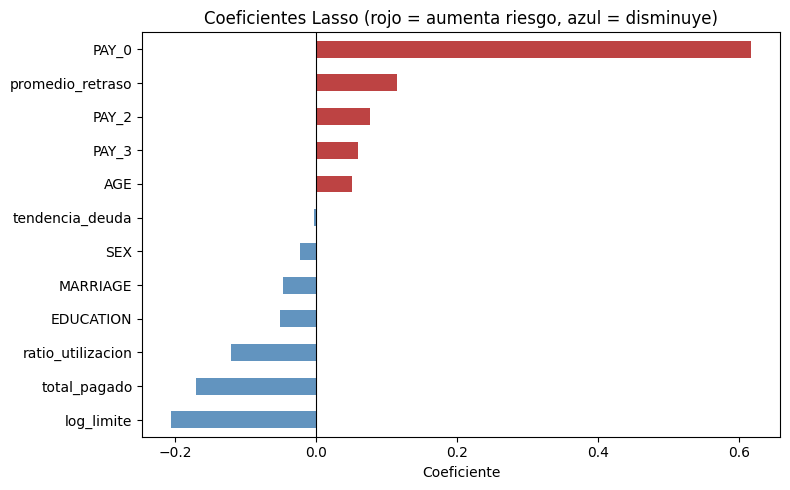

In [29]:
# visualizar los coeficientes
coef_no_cero = coeficientes[coeficientes != 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['firebrick' if v > 0 else 'steelblue' for v in coef_no_cero.values]
coef_no_cero.plot(kind='barh', ax=ax, color=colores, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Lasso (rojo = aumenta riesgo, azul = disminuye)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

---
## Paso 6 — Evaluar el modelo: ¿por qué el accuracy no es suficiente?

Una vez entrenado el modelo, debemos evaluar qué tan bien predice. La métrica más conocida es el **accuracy**, que mide el porcentaje de observaciones clasificadas correctamente.

El problema es que nuestro dataset está **desbalanceado**: cerca del **78% de los clientes no hace default**. Un modelo que siempre predijera "no default" tendría un **78% de accuracy**, aunque nunca detectara un cliente riesgoso. Por eso, en clasificación no basta con mirar el accuracy.

### Matriz de confusión

La matriz de confusión resume los aciertos y errores del modelo:

|  | Predijo NO default | Predijo SÍ default |
|---|---|---|
| **Real: NO default** | ✓ Verdadero Negativo (TN) | ✗ Falso Positivo (FP) |
| **Real: SÍ default** | ✗ Falso Negativo (FN) | ✓ Verdadero Positivo (TP) |

### Precision y Recall

La regresión logística predice una **probabilidad**. Luego se fija un **umbral** (por ejemplo, 0.5): si la probabilidad es mayor al umbral, el modelo predice **default**; si es menor, predice **no default**.

- **Precision:** de los clientes que el modelo predijo como default, ¿cuántos realmente hicieron default?

$$
\text{Precision}=\frac{TP}{TP+FP}
$$

- **Recall:** de los clientes que realmente hicieron default, ¿a cuántos logró detectar?

$$
\text{Recall}=\frac{TP}{TP+FN}
$$

Al bajar el umbral aumenta el **recall**, pero también suelen aumentar los **falsos positivos**, reduciendo la **precision**. El **F1-score** resume este equilibrio:

$$
F1=2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
$$

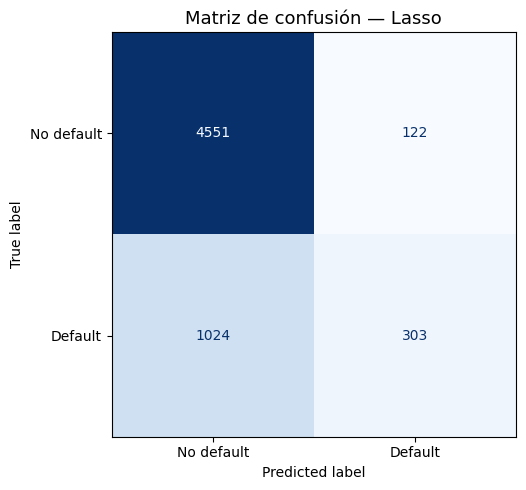


Verdaderos Negativos (TN):  4551  (97.4% de los no-defaults) — predijo bien ✓
Falsos Positivos     (FP):   122  (2.6% de los no-defaults) — alarma falsa ✗
Falsos Negativos     (FN):  1024  (77.2% de los defaults)    — default no detectado ✗ (más costoso)
Verdaderos Positivos (TP):   303  (22.8% de los defaults)    — predijo bien ✓

De cada 100 clientes que SÍ defaultearon, el modelo detectó 23


In [30]:
# .predict() predice la clase (0 o 1) para cada observación del test set
y_pred_lasso = lasso.predict(X_test_scaled)

# .predict_proba() predice la PROBABILIDAD de cada clase
# [:, 1] toma la probabilidad de la clase 1 (default)
y_prob_lasso = lasso.predict_proba(X_test_scaled)[:, 1]

# matriz de confusión
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lasso,
                               display_labels=['No default', 'Default'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Lasso', fontsize=13)
plt.tight_layout()
plt.show()

# totales para calcular porcentajes
total     = cm_lasso.sum()
total_neg = cm_lasso[0].sum()   # todos los que realmente NO defaultearon
total_pos = cm_lasso[1].sum()   # todos los que realmente SÍ defaultearon

tn = cm_lasso[0, 0]
fp = cm_lasso[0, 1]
fn = cm_lasso[1, 0]
tp = cm_lasso[1, 1]

print(f"\nVerdaderos Negativos (TN): {tn:>5}  ({tn/total_neg*100:.1f}% de los no-defaults) — predijo bien ✓")
print(f"Falsos Positivos     (FP): {fp:>5}  ({fp/total_neg*100:.1f}% de los no-defaults) — alarma falsa ✗")
print(f"Falsos Negativos     (FN): {fn:>5}  ({fn/total_pos*100:.1f}% de los defaults)    — default no detectado ✗ (más costoso)")
print(f"Verdaderos Positivos (TP): {tp:>5}  ({tp/total_pos*100:.1f}% de los defaults)    — predijo bien ✓")
print(f"\nDe cada 100 clientes que SÍ defaultearon, el modelo detectó {tp/total_pos*100:.0f}")

In [31]:
# reporte completo de métricas
# classification_report calcula precision, recall y f1 para cada clase
print("Reporte de clasificación — Lasso:")
print(classification_report(y_test, y_pred_lasso,
                             target_names=['No default', 'Default']))

# AUC-ROC: mide la capacidad discriminativa del modelo
# 0.5 = modelo aleatorio, 1.0 = modelo perfecto
auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"AUC-ROC: {auc_lasso:.4f}")

Reporte de clasificación — Lasso:
              precision    recall  f1-score   support

  No default       0.82      0.97      0.89      4673
     Default       0.71      0.23      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

AUC-ROC: 0.7074


In [21]:
# ── Demostrar la trampa del accuracy ──────────────────────────────────────────
# un modelo que siempre predice 'no default' tiene accuracy alta pero es inútil

y_siempre_cero = np.zeros(len(y_test))   # siempre predice no default

from sklearn.metrics import accuracy_score

acc_lasso     = accuracy_score(y_test, y_pred_lasso)
acc_cero      = accuracy_score(y_test, y_siempre_cero)
f1_lasso      = f1_score(y_test, y_pred_lasso)
f1_cero       = f1_score(y_test, y_siempre_cero)

print("Comparación de métricas:\n")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1 (default)':>14}")
print("-" * 56)
print(f"{'Lasso':<30} {acc_lasso:>10.3f} {f1_lasso:>14.3f}")
print(f"{'Siempre predice no-default':<30} {acc_cero:>10.3f} {f1_cero:>14.3f}")
print()
print("El modelo 'siempre no-default' tiene accuracy similar pero F1=0")
print("No detecta ningún default — completamente inútil para el banco")

Comparación de métricas:

Modelo                           Accuracy   F1 (default)
--------------------------------------------------------
Lasso                               0.788          0.118
Siempre predice no-default          0.779          0.000

El modelo 'siempre no-default' tiene accuracy similar pero F1=0
No detecta ningún default — completamente inútil para el banco


---
## Paso 7 — Random Forest

### ¿Qué es un árbol de decisión?

Un árbol de decisión divide el espacio de variables en regiones. Cada nodo hace una pregunta binaria (`PAY_0 > 1?`, `LIMIT_BAL < 50000?`) y divide los datos en dos grupos. Al final, cada hoja del árbol predice una clase.

El problema de los árboles individuales es que son muy sensibles a los datos de entrenamiento — cambian mucho si cambias un poco los datos. Tienen **alta varianza**.

### ¿Qué es un Random Forest?

La solución es construir **muchos árboles** con variaciones aleatorias y promediar sus predicciones. Eso es un Random Forest:

1. Para cada árbol, toma una **muestra aleatoria con reemplazo** del training set (bootstrapping)
2. En cada nodo, solo considera un **subconjunto aleatorio de variables** para hacer el split
3. El resultado final es el **voto de la mayoría** de todos los árboles

La aleatoriedad hace que los árboles sean distintos entre sí. Al promediarlos, los errores de unos se cancelan con los de otros — **reducción de varianza**.

A diferencia de Lasso, Random Forest puede capturar relaciones **no lineales** entre variables.

In [22]:
# n_estimators = número de árboles en el bosque
#   más árboles = más estable pero más lento
#   100-200 es un buen punto de partida
#
# max_depth = profundidad máxima de cada árbol
#   sin límite los árboles memorizan el training set (overfitting)
#   10-20 es razonable para este dataset
#
# min_samples_leaf = mínimo de observaciones en cada hoja
#   evita que el árbol cree hojas con muy pocas observaciones
#
# n_jobs=-1 = usar todos los núcleos disponibles para paralelizar

rf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 15,
    min_samples_leaf = 10,
    n_jobs           = -1,
    random_state     = 42
)

# Random Forest no necesita escalado — los árboles son invariantes a la escala
# usamos X_train (sin escalar) directamente
rf.fit(X_train, y_train)

print("Random Forest entrenado ✓")

Random Forest entrenado ✓


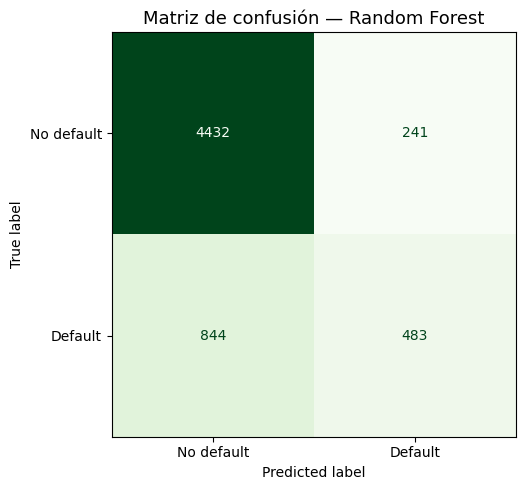

Reporte de clasificación — Random Forest:
              precision    recall  f1-score   support

  No default       0.84      0.95      0.89      4673
     Default       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

AUC-ROC: 0.7789


In [23]:
# evaluar Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['No default', 'Default'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de confusión — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print("Reporte de clasificación — Random Forest:")
print(classification_report(y_test, y_pred_rf,
                             target_names=['No default', 'Default']))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC-ROC: {auc_rf:.4f}")

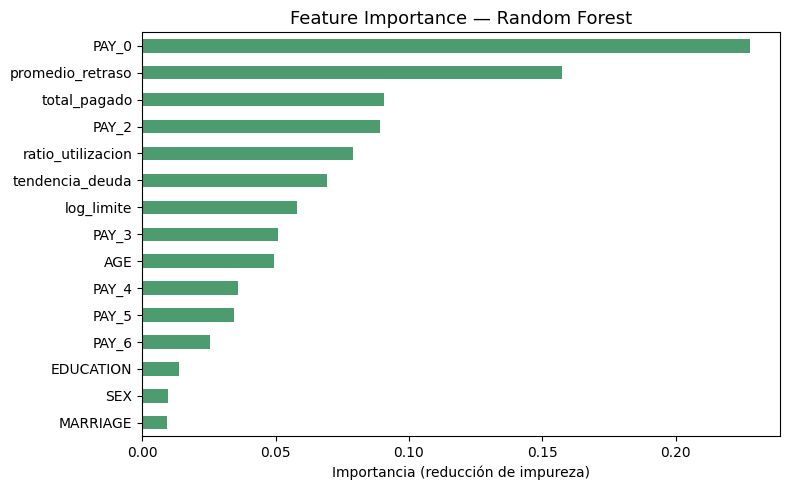

In [24]:
# feature importance del Random Forest
# mide cuánto contribuye cada variable a la reducción de impureza en los árboles
# a diferencia de los coeficientes de Lasso, captura relaciones no lineales

importancias = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='seagreen', alpha=0.85)
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.show()

---
## Paso 8 — Comparar los dos modelos

In [25]:
from sklearn.metrics import accuracy_score

resultados = pd.DataFrame({
    'Modelo'  : ['Lasso', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lasso),
                 accuracy_score(y_test, y_pred_rf)],
    'F1'      : [f1_score(y_test, y_pred_lasso),
                 f1_score(y_test, y_pred_rf)],
    'AUC-ROC' : [auc_lasso, auc_rf]
}).set_index('Modelo').round(4)

print("Comparación de modelos en el test set:")
print(resultados)

Comparación de modelos en el test set:
               Accuracy      F1  AUC-ROC
Modelo                                  
Lasso            0.7878  0.1178   0.6986
Random Forest    0.8192  0.4710   0.7789


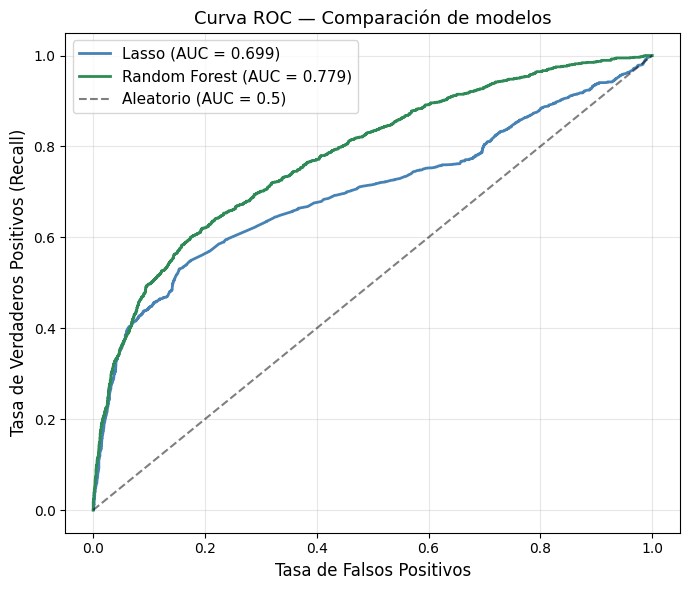

In [26]:
# Curva ROC — muestra el trade-off entre recall y tasa de falsos positivos
# en distintos umbrales de clasificación
# el área bajo la curva (AUC) resume la calidad discriminativa del modelo

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))

for nombre, y_prob, color in [
    ('Lasso', y_prob_lasso, 'steelblue'),
    ('Random Forest', y_prob_rf, 'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nombre} (AUC = {auc:.3f})')

# línea diagonal = modelo aleatorio (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curva ROC — Comparación de modelos', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Resumen

| | Lasso | Random Forest |
|---|---|---|
| **Tipo** | Lineal con regularización | Ensamble de árboles |
| **Selección de variables** | Automática (coef → 0) | Por importancia |
| **Relaciones no lineales** | No | Sí |
| **Interpretabilidad** | Alta (coeficientes) | Media (importancias) |
| **Necesita escalado** | Sí | No |

**Lo más importante de la clase:** accuracy no es suficiente cuando los datos están desbalanceados. Para predecir defaults, el banco necesita un modelo con buen **recall** (no perder defaults reales) balanceado con buena **precision** (no restringir crédito innecesariamente). **F1 captura ese balance**.

En la siguiente clase: ElasticNet y XGBoost.